In [1]:
from pathlib import Path
import json
import pandas as pd

NAME  = "NDM5_KPC3_boltz2"

# Base folder with all peptide_* subfolders
PRED_DIR = Path(NAME)

In [3]:
records = []

for json_path in PRED_DIR.rglob("confidence_peptide_*_target_*_model_0.json"):
    rel = json_path.relative_to(PRED_DIR)
    peptide_dir = rel.parts[0]

    with open(json_path, "r") as f:
        data = json.load(f)

    rec = {"peptide_num": peptide_dir.split("_")[1], "target": peptide_dir.split("_")[-1]}

    # Copy top-level scalar fields, but round floats to 4 decimals where possible
    for k, v in data.items():
        if isinstance(v, float):
            rec[k] = round(v, 4)
        else:
            rec[k] = v

    # Flatten chains_ptm and round values
    for chain_id, v in data.get("chains_ptm", {}).items():
        rec[f"chains_ptm_{chain_id}"] = round(v, 4) if isinstance(v, float) else v

    # Flatten pair_chains_iptm and round values
    for c1, inner in data.get("pair_chains_iptm", {}).items():
        for c2, v in inner.items():
            rec[f"pair_chains_iptm_{c1}_{c2}"] = round(v, 4) if isinstance(v, float) else v

    records.append(rec)

df = pd.DataFrame(records).sort_values(["iptm"], ascending=False)
for col in ['ligand_iptm', 'chains_ptm', 'pair_chains_iptm', 'protein_iptm']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
df.reset_index(drop=True, inplace=True)

csv_path = Path(f"../data/tables/boltz2_confidence_summary_{NAME}.csv")
df.to_csv(csv_path, index=False)
df.head()

,peptide_num,target,confidence_score,ptm,iptm,complex_plddt,complex_iplddt,complex_pde,complex_ipde,chains_ptm_0,chains_ptm_1,pair_chains_iptm_0_0,pair_chains_iptm_0_1,pair_chains_iptm_1_0,pair_chains_iptm_1_1
0,28,NDM5,0.9104,0.9194,0.9499,0.9006,0.8866,0.3771,1.2194,0.9620,0.9189,0.9620,0.9499,0.7580,0.9189
1,117,NDM5,0.9235,0.9088,0.9464,0.9177,0.8975,0.4311,1.1699,0.9513,0.9078,0.9513,0.9464,0.7381,0.9078
2,173,NDM5,0.8904,0.9351,0.9439,0.8770,0.8240,0.3513,0.9059,0.9430,0.9352,0.9430,0.9439,0.8027,0.9352
3,196,NDM5,0.8931,0.9166,0.9396,0.8815,0.8138,0.3968,1.4187,0.9781,0.9158,0.9781,0.9396,0.7966,0.9158
4,179,NDM5,0.9081,0.9214,0.9394,0.9003,0.8698,0.3969,1.1780,0.9390,0.9212,0.9390,0.9394,0.7676,0.9212


In [7]:
import numpy as np

path = "boltz2_predictions/peptide_0/plddt_peptide_0_model_0.npz"

data = np.load(path)          # returns an NpzFile object
print(data.files)             # list of array names inside

arr = data[data.files[0]]     # first array, e.g. pLDDT values
print(arr.shape, arr.dtype)

['plddt']
(275,) float32


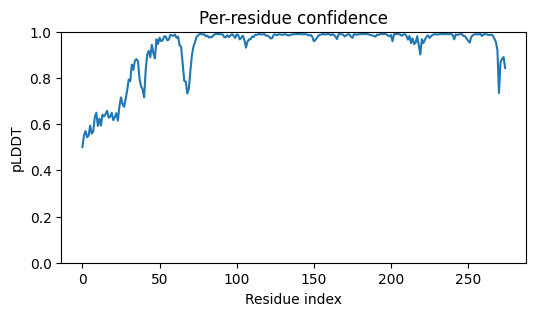

In [10]:
import matplotlib.pyplot as plt
import numpy as np

data = np.load("boltz2_predictions/peptide_0/plddt_peptide_0_model_0.npz")
plddt = data[data.files[0]]          # 1D array

plt.figure(figsize=(6, 3))
plt.plot(plddt)
plt.xlabel("Residue index")
plt.ylabel("pLDDT")
plt.ylim(0, 1)
plt.title("Per-residue confidence")
plt.show()

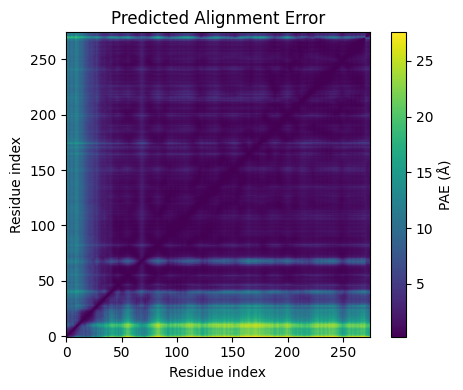

In [11]:
import matplotlib.pyplot as plt
import numpy as np

data = np.load("boltz2_predictions/peptide_0/pae_peptide_0_model_0.npz")
pae = data[data.files[0]]           # 2D (L x L) matrix

plt.figure(figsize=(5, 4))
im = plt.imshow(pae, cmap="viridis", origin="lower")
plt.colorbar(im, label="PAE (Å)")
plt.xlabel("Residue index")
plt.ylabel("Residue index")
plt.title("Predicted Alignment Error")
plt.tight_layout()
plt.show()